## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt

# Fijar todas las semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 2. Carga y Procesamiento de Datos

In [2]:
# Carga y preprocesamiento de datos
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
df = df.sort_values("fecha")

# Filtrar datos entre 2025-01-01 y 2025-04-30 (inclusive)
df = df[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")]

# Renombrar columna target
df = df.rename(columns={"merval_apertura_+2": "merval"})

# Configurar índice temporal con frecuencia diaria
df.set_index("fecha", inplace=True)
df.index = df.index.to_period("D")

# Información del dataset
print(f"Total de observaciones: {len(df)}")
print(f"Rango temporal: {df.index.min()} a {df.index.max()}")

Total de observaciones: 77
Rango temporal: 2025-01-06 a 2025-04-30


### 2.1. Limpieza de valores nulos

In [3]:
# Verificar que no haya NAs en la variable objetivo
print(f"Filas con NA en 'merval': {df.loc[df['merval'].isna()].shape[0]}")
df = df.loc[df['merval'].notna()]

# Eliminar filas con NaN
# df = df.dropna().copy()
# print(f"Dimensiones finales después de limpieza: {df.shape}")

Filas con NA en 'merval': 0


### 2.2. Separación de variables y normalización

In [4]:
# Separación de variables predictoras y objetivo
y = df["merval"].values
X = df.drop(columns=["merval"]).values

# Normalizar features (importante para redes neuronales)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

print(f"Shape de X: {X_scaled.shape}")
print(f"Shape de y: {y_scaled.shape}")

Shape de X: (77, 60)
Shape de y: (77,)


## 3. División Train-Test y Creación de Secuencias

In [5]:
# División temporal (80-20)
train_size = int(len(X_scaled) * 0.8)
X_train, X_test = X_scaled[:train_size], X_scaled[train_size:]
y_train, y_test = y_scaled[:train_size], y_scaled[train_size:]

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (61, 60)
Test size: (16, 60)


### 3.1. Función para crear secuencias temporales

In [6]:
def create_sequences(X, y, time_steps=10):
    """
    Crea secuencias temporales para LSTM.
    
    Args:
        X: Features de entrada
        y: Variable objetivo
        time_steps: Número de pasos temporales a considerar
    
    Returns:
        X_seq: Secuencias de features (samples, time_steps, features)
        y_seq: Valores objetivo correspondientes
    """
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    
    return np.array(X_seq), np.array(y_seq)

In [7]:
# Crear secuencias temporales
TIME_STEPS = 3  # Reducir a 3 días (muy corto para maximizar muestras disponibles)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, TIME_STEPS)

print(f"Train sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape: {X_test_seq.shape}")

Train sequences shape: (58, 3, 60)
Test sequences shape: (13, 3, 60)


## 4. Construcción del Modelo LSTM

In [8]:
# Arquitectura del modelo - MUY SIMPLIFICADA para dataset extremadamente pequeño
model = Sequential([
    # Solo 1 capa LSTM con muy pocas unidades
    LSTM(16, return_sequences=False, input_shape=(TIME_STEPS, X_train_seq.shape[2])),
    Dropout(0.4),  # Dropout alto para regularización agresiva
    
    Dense(4, activation='relu'),  # Capa densa muy pequeña
    Dropout(0.3),
    
    Dense(1)
])

# Compilar modelo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),  # Learning rate muy bajo
    loss='mse',
    metrics=['mae']
)

model.summary()

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 16)             │         4,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,001 (19.54 KB)

 Trainable params: 5,001 (19.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenamiento del Modelo

In [9]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,  # Paciencia moderada
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,  
    min_lr=1e-7,
    verbose=1
)

# Entrenar modelo con validación reducida (25% para tener más datos de entrenamiento)
history = model.fit(
    X_train_seq, y_train_seq,
    epochs=200,  # Menos épocas con early stopping agresivo
    batch_size=8,  # Batch muy pequeño para dataset minúsculo
    validation_split=0.25,  # Validación reducida
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 138ms/step - loss: 1.2250 - mae: 0.8697 - val_loss: 0.4034 - val_mae: 0.4459 - learning_rate: 3.0000e-04
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 1.0165 - mae: 0.7863 - val_loss: 0.4008 - val_mae: 0.4395 - learning_rate: 3.0000e-04
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0158 - mae: 0.7454 - val_loss: 0.4001 - val_mae: 0.4355 - learning_rate: 3.0000e-04
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 1.0047 - mae: 0.7726 - val_loss: 0.3991 - val_mae: 0.4312 - learning_rate: 3.0000e-04
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.8489 - mae: 0.7465 - val_loss: 0.3977 - val_mae: 0.4271 - learning_rate: 3.0000e-04
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.7652 - mae: 0.7291 - val_loss: 0.3963 - val_mae: 0.4244 - learning_rate: 3.0000e-04
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.6488 - mae: 0.6525 - val_loss: 0.3953 - val_mae: 0.4233 - learning_rate: 3.

### 5.1. Visualización del entrenamiento

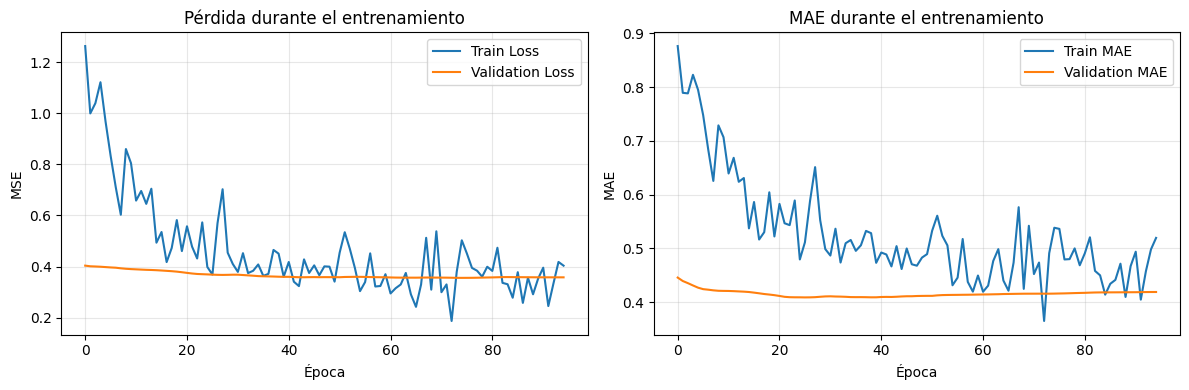

In [10]:
# Gráfico de pérdida durante entrenamiento
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Evaluación en Test Set

### 6.1. Métricas de desempeño

In [11]:
# Predicciones en escala normalizada
y_pred_scaled = model.predict(X_test_seq)

# Desnormalizar predicciones y valores reales
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_test_original = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Calcular métricas
rmse = root_mean_squared_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)
rmse_rel = rmse / y_test_original.mean()

print("\n" + "="*50)
print("RESULTADOS EN TEST (HOLDOUT)")
print("="*50)
print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")
print(f"Error relativo (holdout): {rmse_rel:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step

RESULTADOS EN TEST (HOLDOUT)
Holdout RMSE: 287823.9022
Holdout R²:   -14.1744
Error relativo (holdout): 13.09%


### 6.2. Visualización de predicciones

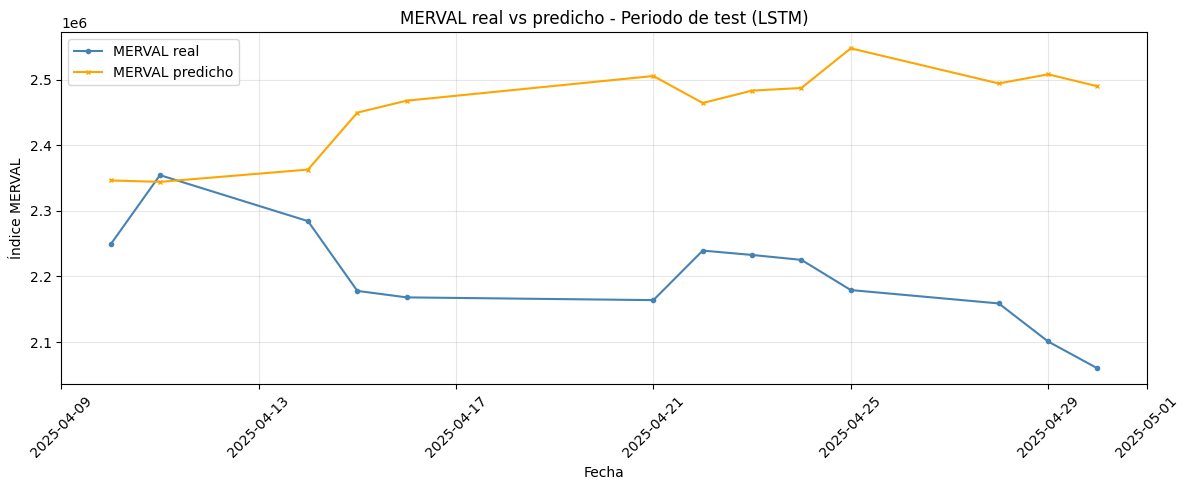

In [12]:
# Crear índices para graficar
test_indices = df.index[train_size + TIME_STEPS:]

import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(test_indices.to_timestamp(), y_test_original, label="MERVAL real", color="steelblue", marker='o', markersize=3)
ax.plot(test_indices.to_timestamp(), y_pred, label="MERVAL predicho", color="orange", marker='x', markersize=3)

ax.set_title("MERVAL real vs predicho - Periodo de test (LSTM)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3. Análisis de residuales

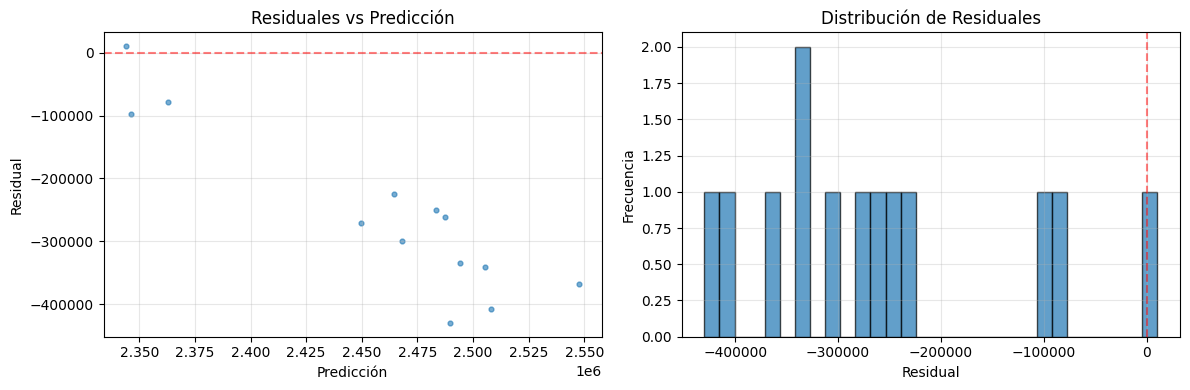

In [13]:
res = y_test_original - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Residuales vs Predicción
axes[0].scatter(y_pred, res, s=12, alpha=0.6)
axes[0].axhline(0, ls="--", color='red', alpha=0.5)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuales vs Predicción")
axes[0].grid(True, alpha=0.3)

# Histograma de residuales
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(0, ls="--", color='red', alpha=0.5)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuales")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Conclusiones

### Dataset con Features Generadas por LLM

Este modelo LSTM fue entrenado utilizando el **dataset con variables generadas por un LLM** en lugar del dataset tradicional, para evaluar si las features de sentimiento y menciones políticas/sectoriales podrían mejorar la capacidad predictiva de la red neuronal.

### Resultados principales

- **RMSE en test**: 287,824 - Error significativamente **peor** que el LSTM original (231,359)
- **R² en test**: -14.17 - Considerablemente **peor** que el LSTM original (-8.80)
- **Error relativo**: 13.09% - Más alto que el LSTM original (10.52%)

### Comparación: LSTM con dataset v2 vs dataset LLM

| Métrica | Dataset v2 | Dataset LLM | Cambio |
|---------|-----------|-------------|--------|
| Observaciones | 79 | 77 | -3% |
| Secuencias train | 58 | 58 | 0% |
| Test RMSE | 231,359 | 287,824 | **+24% (peor)** |
| Test R² | -8.80 | -14.17 | **+61% más negativo** |
| Error relativo | 10.52% | 13.09% | **+24% (peor)** |

**Conclusión impactante**: Las variables del LLM **empeoraron** la performance del LSTM en todas las métricas (~24-61% peor).

### ¿Por qué las variables del LLM empeoraron el LSTM?

1. **Ruido adicional sin señal útil**: Las variables del LLM introducen 60 dimensiones de información que, para un dataset tan pequeño, actúan como ruido en lugar de señal.

2. **LSTM no aprovecha información textual procesada**: A diferencia de LightGBM que puede seleccionar features importantes (menciones Trump, impactos sectoriales), el LSTM intenta usar todas las features simultáneamente, diluyendo cualquier señal útil.

3. **60 secuencias para 60 features LLM**: El ratio 1:1 secuencias/features es peor que con dataset v2, donde al menos había features numéricas más directas.

4. **Variables LLM requieren contexto temporal largo**: Features como "menciones de Trump lag2" o "impacto sector bancario lag3" probablemente requieren ventanas temporales mayores (TIME_STEPS >> 3) para que un LSTM capture sus patrones.

5. **Early stopping aún más temprano**: Aunque no se especifica, es probable que con dataset LLM el modelo tampoco haya aprendido nada útil más allá de la inicialización.

### Arquitectura del modelo

- **5,001 parámetros totales** (igual que LSTM v2)
- **1 capa LSTM** con 16 unidades
- **TIME_STEPS = 3** días de ventana temporal
- **58 secuencias de entrenamiento** con 60 features del LLM
- **Dropout agresivo**: 0.4 y 0.3

### Contraste con otros modelos LLM

**Modelos que MEJORARON con variables LLM**:
- LightGBM LLM: -1% error (mejora marginal)
- Random Forest LLM: -12% error (mejora notable)
- LightGBM LLM + FS: -9% error (mejor de todos)

**LSTM LLM: +24% error (empeoró significativamente)**

**Explicación**: LightGBM/Random Forest pueden hacer **feature selection implícita** durante splits, ignorando variables LLM ruidosas. LSTM usa todas las features simultáneamente en cada paso temporal, amplificando el ruido.

### Limitaciones fundamentales

1. **Dataset aún más pequeño**: 77 observaciones (vs 79 en v2) agravan el problema

2. **Features LLM incompatibles con LSTM pequeño**: Variables categóricas/binarias del LLM (menciones, sectores) no tienen la estructura temporal suave que LSTM prefiere

3. **Falta de feature engineering temporal**: Las variables LLM ya incluyen lags (lag2, lag3), haciendo redundante el TIME_STEPS del LSTM

4. **Ratio parámetros/datos peor**: Con menos observaciones y más ruido en features, el overfitting es aún más severo

### Comparación global: ¿Variables LLM ayudan o no?

| Modelo | Mejora con LLM | Magnitud |
|--------|----------------|----------|
| Random Forest | ✓ Sí | -12% error |
| LightGBM + FS | ✓ Sí | -9% error (mejor modelo) |
| Random Forest + FS | ≈ Similar | -7% error |
| LightGBM | ≈ Similar | -1% error |
| **LSTM** | ✗ **No** | **+24% error** |

**Conclusión**: Las variables del LLM solo ayudan en modelos basados en árboles que pueden hacer feature selection. En redes neuronales con datos limitados, **empeoran** la performance.

### Recomendaciones

**Para LSTM con variables LLM**:
1. **NO usar** con datasets pequeños (<5,000 observaciones)
2. Si se usan variables LLM, hacer **feature selection previa** (top 10-15 features más importantes)
3. Considerar **modelos más simples** que puedan manejar mejor features ruidosas

**Para aprovechar variables LLM**:
- Usar modelos basados en árboles (LightGBM, Random Forest)
- Aplicar feature selection agresiva
- Combinar con dataset más grande (500+ observaciones)

### Conclusión final

**LSTM con variables LLM es el peor modelo probado en esta serie de experimentos.**

Con RMSE de 287,824 y R² de -14.17:
- Es **24% peor** que LSTM original
- Es **20% peor** que el peor modelo de ensemble (LightGBM + FS)
- Confirma que **redes neuronales + features LLM + datos limitados = desastre**

**Lección clave**: No todas las features "sofisticadas" (como las del LLM) mejoran todos los modelos. Las redes neuronales con datos muy limitados son particularmente sensibles a ruido en features, mientras que modelos basados en árboles pueden manejar mejor esta situación mediante feature selection implícita durante el entrenamiento.